## Variational GPR on WeatherBench Data 
Apply GP regression baseline


In [1]:
# Check GPU
!nvidia-smi

Sat Mar  8 23:18:41 2025       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.12             Driver Version: 535.104.12   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA A100-PCIE-40GB          Off | 00000000:1B:00.0 Off |                    0 |
| N/A   41C    P0              36W / 250W |  24065MiB / 40960MiB |      1%      Default |
|                                         |                      |             Disabled |
+-----------------------------------------+----------------------+--

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import seaborn as sns
import pickle
import time
from tqdm.notebook import tqdm

import torch
from torch.utils.data import TensorDataset, DataLoader

import gpytorch
from gpytorch.models import ApproximateGP
from gpytorch.variational import CholeskyVariationalDistribution, VariationalStrategy

In [3]:
torch.set_default_dtype(torch.float64)

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Data Processing

Loading the data

In [5]:
z500 = xr.open_mfdataset('STGP-weather-forecasting/data/5.625deg/geopotential_500/*.nc', combine='by_coords')
z500_train = z500.sel(time=slice('2017.12', '2017.12'))['z']
z500_test = z500.sel(time=slice('2018.1', '2018.1.7'))['z'] # 2017-2018 data

In [6]:
data_mean = z500_train.mean().load()
data_std = z500_train.std().load()

# Normalize datasets
data_train = (z500_train - data_mean) / data_std
data_test = (z500_test - data_mean) / data_std

We need to convert (lat., lon.) coordinates into (x,y,z) for the inputs into the spatial kernel from GeometricKernel 

In [7]:
def latlon_to_cartesian(lat, lon, device=device):
    """ Converting (lat., lon.) to cartesian coordinates on a unit sphere
        Note: WeatherBench data is defined on a constant altitude """

    lat, lon = np.deg2rad(lat), np.deg2rad(lon)

    x = np.cos(lat)[:, None] * np.cos(lon)[None, :]
    y = np.cos(lat)[:, None] * np.sin(lon)[None, :]
    z = np.sin(lat)[:, None] * np.ones_like(lon)[None, :]

    xyz = np.stack([x, y, z], axis=-1)  # Out: (nlat, nlon, 3)
    return torch.tensor(xyz).to(device)

Subsampling the datasets due to memory issues

In [8]:
def create_data(data_train, data_test, lead_time_h, space_subsample=1, time_subsample=1, device=device, train=True):
    """Preparing input and output data. X should be the coordinate input into the kernel, 
    while Y should be the forecast target (shifted lead time)."""

    # Training Data
    X = data_train.isel(time=slice(0, -lead_time_h, time_subsample),
                        lat=slice(0, None, space_subsample),
                        lon=slice(0, None, space_subsample))
    Y = data_train.isel(time=slice(lead_time_h, None, time_subsample),
                  lat=slice(0, None, space_subsample),
                  lon=slice(0, None, space_subsample)) 

    # Preparing the input coords (should have shape (ntime, nlat, nlon, 4) if we have no subsampling)
    X_time = (X.time - data_train.time[0]).values / np.timedelta64(1, 'h')
    X_time = torch.tensor(X_time).to(device)
    t_steps = X_time.shape[0]

    latitudes = X.lat.values 
    longitudes = X.lon.values 
    cartesian_coords = latlon_to_cartesian(latitudes, longitudes, device)
    nlat, nlon, _ = cartesian_coords.shape

    if train:
        print("Processing Training Dataset")
        # Combine spatial and temporal data
        training_coords = torch.empty((t_steps, nlat, nlon, 4)).to(device)
        # Fill in the spatial part first
        training_coords[..., :3] = cartesian_coords.unsqueeze(0).expand(t_steps, -1, -1, -1)
        # The final element is time
        training_coords[..., 3] = X_time.view(t_steps, 1, 1).expand(t_steps, nlat, nlon)
        X_size = training_coords.element_size() * training_coords.nelement() / (1024**2)
        print(f"Combined coords info --> Shape: {training_coords.shape}, Mem: {X_size:.2f} MB")

        # Flatten to shape (N,)
        Y = torch.tensor(Y.values).view(-1).to(device)
        Y_size = Y.element_size() * Y.nelement() / (1024**2)
        print(f"Target info --> Shape: {Y.shape}, Mem: {Y_size:.2f} MB")

        return training_coords, Y
    
    else:
        # Testing Data
        X_test = data_test.isel(time=slice(0, -lead_time_h, time_subsample),
                            lat=slice(0, None, space_subsample),
                            lon=slice(0, None, space_subsample))
        Y_test = data_test.isel(time=slice(lead_time_h, None, time_subsample),
                    lat=slice(0, None, space_subsample),
                    lon=slice(0, None, space_subsample))
        X_test_time = (X_test.time - data_train.time[0]).values / np.timedelta64(1, 'h')
        X_test_time = torch.tensor(X_test_time).to(device)
        test_t_steps = X_test_time.shape[0]

        print("Processing Test Dataset")
        # Combine spatial and temporal data
        testing_coords = torch.empty((test_t_steps, nlat, nlon, 4)).to(device)
        # Fill in the spatial part first
        testing_coords[..., :3] = cartesian_coords.unsqueeze(0).expand(test_t_steps, -1, -1, -1)
        # The final element is time
        testing_coords[..., 3] = X_test_time.view(test_t_steps, 1, 1).expand(test_t_steps, nlat, nlon)
        X_size = testing_coords.element_size() * testing_coords.nelement() / (1024**2)
        print(f"Combined coords info --> Shape: {testing_coords.shape}, Mem: {X_size:.2f} MB")

        # Flatten to shape (N,)
        Y_test = torch.tensor(Y_test.values).view(-1).to(device)
        Y_size = Y_test.element_size() * Y_test.nelement() / (1024**2)
        print(f"Target info --> Shape: {Y_test.shape}, Mem: {Y_size:.2f} MB")

        return testing_coords, Y_test, latitudes, longitudes

## Defining the Kernel

We work on the 2d-hypersphere, modeling the spatial kernel with Geometric_Kernel and time kernel with periodic kernel. 

In [9]:
# Define the GP regression kernel, separable in space and time
matern_spatial_1 = gpytorch.kernels.MaternKernel(nu=1.5, active_dims=[0,1,2]).to(device)
matern_spatial_1.lengthscale = torch.tensor(0.5).to(device)
#matern_spatial_1.register_prior("lengthscale_prior", gpytorch.priors.NormalPrior(0.5, 0.1), "lengthscale")

matern_spatial_2 = gpytorch.kernels.MaternKernel(nu=1.5, active_dims=[0,1,2]).to(device)
matern_spatial_2.lengthscale = torch.tensor(1.5).to(device)
#matern_spatial_2.register_prior("lengthscale_prior", gpytorch.priors.NormalPrior(1.5, 0.3), "lengthscale")

matern_spatial_3 = gpytorch.kernels.MaternKernel(nu=1.5, active_dims=[0,1,2]).to(device)
matern_spatial_3.lengthscale = torch.tensor(3).to(device)
#matern_spatial_3.register_prior("lengthscale_prior", gpytorch.priors.NormalPrior(3.0, 0.6), "lengthscale")

spatial_kernel = gpytorch.kernels.ScaleKernel(matern_spatial_1+matern_spatial_2+matern_spatial_3).to(device)

In [10]:
# For temporal kernel
time_kernel1 = gpytorch.kernels.PeriodicKernel(active_dims=[3]).to(device) # Daily    
time_kernel1.period_length = torch.tensor(24).to(device)
time_kernel2 = gpytorch.kernels.PeriodicKernel(active_dims=[3]).to(device) # Three days
time_kernel2.period_length = torch.tensor(24*3).to(device)
time_kernel3 = gpytorch.kernels.PeriodicKernel(active_dims=[3]).to(device) # Weekly
time_kernel3.period_length = torch.tensor(24*7).to(device)

#time_kernel1.register_prior("period_length_prior", gpytorch.priors.NormalPrior(24, 3), "period_length")
#time_kernel2.register_prior("period_length_prior", gpytorch.priors.NormalPrior(24*3, 9), "period_length")
#time_kernel3.register_prior("period_length_prior", gpytorch.priors.NormalPrior(24*7, 21), "period_length")

time_kernel = time_kernel1 + time_kernel2 + time_kernel3

# Construct the product kernel
kernel = spatial_kernel * time_kernel

# Approximate GP
class GPModel(ApproximateGP):
    def __init__(self, inducing_points):
        # inducing_points: tensor of shape (M, 4)
        variational_distribution = CholeskyVariationalDistribution(inducing_points.size(0))
        variational_strategy = VariationalStrategy(self, inducing_points, variational_distribution, learn_inducing_locations=True)
        super(GPModel, self).__init__(variational_strategy)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = kernel

    def forward(self, x):
        # x is expected to be of shape (N, 4) (flattened combined coords)
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

## Training and Evaluation

In [ ]:
def train_gp(lead_time, data_train, data_test, space_subsample_ips, time_subsample_ips, space_subsample=1, time_subsample=1, epochs=3, batch_size=2048, save_model=False, device=device):
    """
    Train a Gaussian Process model using GPyTorch. Can add subsampling the data for efficiency.
    """
    
    # Prepare training data (Here we do not subsample any of the training data)
    X_train, Y_train = create_data(data_train, data_test, lead_time, space_subsample, time_subsample)

    # Inducing points technique
    inducing_points = X_train[::time_subsample_ips, ::space_subsample_ips, ::space_subsample_ips,:].reshape(-1, 4)
    X_train = X_train.view(-1,4) # Shape: (ntime*nlat*nlon, 4)
    print(f"Number of inducing points / Total number of points: {inducing_points.size(0)/X_train.size(0)}")
    
    train_dataset = TensorDataset(X_train, Y_train)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device)
    model = GPModel(inducing_points).to(device)
    
    # Train model
    model.train()
    likelihood.train()

    # Optimizer
    optimizer = torch.optim.Adam([
        {'params': model.parameters()},
        {'params': likelihood.parameters()},
    ], lr=0.001)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.99)

    # Loss fn
    mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=len(train_dataset))

    print("Starting Variational GP regression training:")
    # Reset the peak memory statistics before training
    torch.cuda.reset_peak_memory_stats(device)
    hyperparams_track = []
    start_time = time.time()

    for epoch in range(epochs):
        epoch_loss = 0.0
        batch_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
        for x_batch, y_batch in train_loader:
            optimizer.zero_grad()
            output = model(x_batch)
            # Scale the loss to approximate full-data loss
            loss = -mll(output, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            batch_bar.set_postfix(loss=f"{loss.item():.3f}")
            batch_bar.update(1)

            spatial_kernel = model.covar_module.kernels[0]
            spatial1 = spatial_kernel.base_kernel.kernels[0]
            spatial2 = spatial_kernel.base_kernel.kernels[1]
            spatial3 = spatial_kernel.base_kernel.kernels[2]
            time_sum_kernel = model.covar_module.kernels[1]
            periodic1 = time_sum_kernel.kernels[0]
            periodic2 = time_sum_kernel.kernels[1]
            periodic3 = time_sum_kernel.kernels[2]

            hyperparams_track.append({
                "loss": loss.item(),
                "mean": model.mean_module.constant.item(),
                "noise": likelihood.noise.item(),
                "spatial_1_lengthscale": spatial1.lengthscale.item(),
                "spatial_2_lengthscale": spatial2.lengthscale.item(),
                "spatial_3_lengthscale": spatial3.lengthscale.item(),
                "spatial_outputscale": spatial_kernel.outputscale.item(),
                "time_lengthscale_daily": periodic1.lengthscale.item(),
                "time_period_daily": periodic1.period_length.item(),
                "time_lengthscale_three_days": periodic2.lengthscale.item(),
                "time_period_three_days": periodic2.period_length.item(),
                "time_lengthscale_weekly": periodic3.lengthscale.item() ,
                "time_period_weekly": periodic3.period_length.item(),
            })

        scheduler.step()
        print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss/len(train_loader):.3f}")
            
    current_allocated = torch.cuda.memory_allocated(device)
    max_allocated = torch.cuda.max_memory_allocated(device)
    print(f"Current GPU memory allocated: {current_allocated / (1024**2):.2f} MB")
    print(f"Peak GPU memory allocated: {max_allocated / (1024**2):.2f} MB")

    end_time = time.time()
    print("Training completed")
    time_elapsed = end_time - start_time
    print(f"Training time: {time_elapsed:.2f}s")

    # Save model
    if save_model:
        torch.save(model.state_dict(), "STGP-weather-forecasting/saved_models/vargp_model.pth")
        torch.save(likelihood.state_dict(), "STGP-weather-forecasting/saved_models/vargp_likelihood.pth")
        print("Saved model")

    return model, likelihood, hyperparams_track

In [12]:
lead_time = 24 # units of hours
space_subsample_ips = 5 # regular subsampling as inducing points
time_subsample_ips = 6 # regular subsampling as inducing points
space_subsample = 1
time_subsample = 1
batch_size = 2048

# Train GP model
model, likelihood, hyperparams_track = train_gp(lead_time, data_train, data_test, space_subsample_ips, time_subsample_ips, space_subsample, time_subsample, batch_size=batch_size)

Processing Training Dataset
Combined coords info --> Shape: torch.Size([720, 32, 64, 4]), Mem: 45.00 MB
Target info --> Shape: torch.Size([1474560]), Mem: 5.62 MB
Number of inducing points / Total number of points: 0.007405598958333333
Starting Variational GP regression training:


Epoch 1/3:   0%|          | 0/720 [00:00<?, ?it/s]

Epoch 1/3 - Loss: 1.134


Epoch 2/3:   0%|          | 0/720 [00:00<?, ?it/s]

Epoch 2/3 - Loss: 0.651


Epoch 3/3:   0%|          | 0/720 [00:00<?, ?it/s]

Epoch 3/3 - Loss: 0.402
Current GPU memory allocated: 5871.98 MB
Peak GPU memory allocated: 48879.49 MB
Training completed
Training time: 5321.19s


In [ ]:
X_test, Y_test, lat, lon = create_data(data_train, data_test, lead_time, space_subsample=space_subsample, 
                                                time_subsample=time_subsample, device=device, train=False)
X_test = X_test.view(-1,4)
nlat = len(lat)
nlon = len(lon)

test_dataset = TensorDataset(X_test, Y_test)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Make Predictions
model.eval()
likelihood.eval()
Y_pred = []
Y_std = []
with torch.no_grad():
    for x_batch, _ in test_loader:
        batch_pred = likelihood(model(x_batch))
        Y_pred.append(batch_pred.mean)
        Y_std.append(batch_pred.stddev)
    Y_pred = torch.cat(Y_pred, dim=0)  
    Y_std = torch.cat(Y_std, dim=0) 

    mse = torch.mean((Y_pred - Y_test)**2)
    rmse = torch.sqrt(mse)
    print("MSE: ", mse.item())
    print("RMSE: ", rmse.item())

    Y_pred_actual = (Y_pred.detach().cpu().numpy() * data_std.values + data_mean.values).reshape(-1,nlat,nlon)
    Y_test_actual = (Y_test.detach().cpu().numpy() * data_std.values + data_mean.values).reshape(-1,nlat,nlon)
    err = Y_pred_actual - Y_test_actual
    weights_lat = np.cos(np.deg2rad(lat))
    weights_lat /= weights_lat.mean()
    wrmse = np.sqrt((err**2 * weights_lat[None, :, None]).mean())
    print("Weighted RMSE: ", wrmse)

Y_pred = Y_pred.detach().cpu().numpy()  
Y_test = Y_test.detach().cpu().numpy()  
Y_std = Y_std.detach().cpu().numpy()

Processing Test Dataset
Combined coords info --> Shape: torch.Size([144, 32, 64, 4]), Mem: 9.00 MB
Target info --> Shape: torch.Size([294912]), Mem: 1.12 MB
MSE:  0.08200599826799952
RMSE:  0.28636689450423475
Weighted RMSE:  817.4127557725042


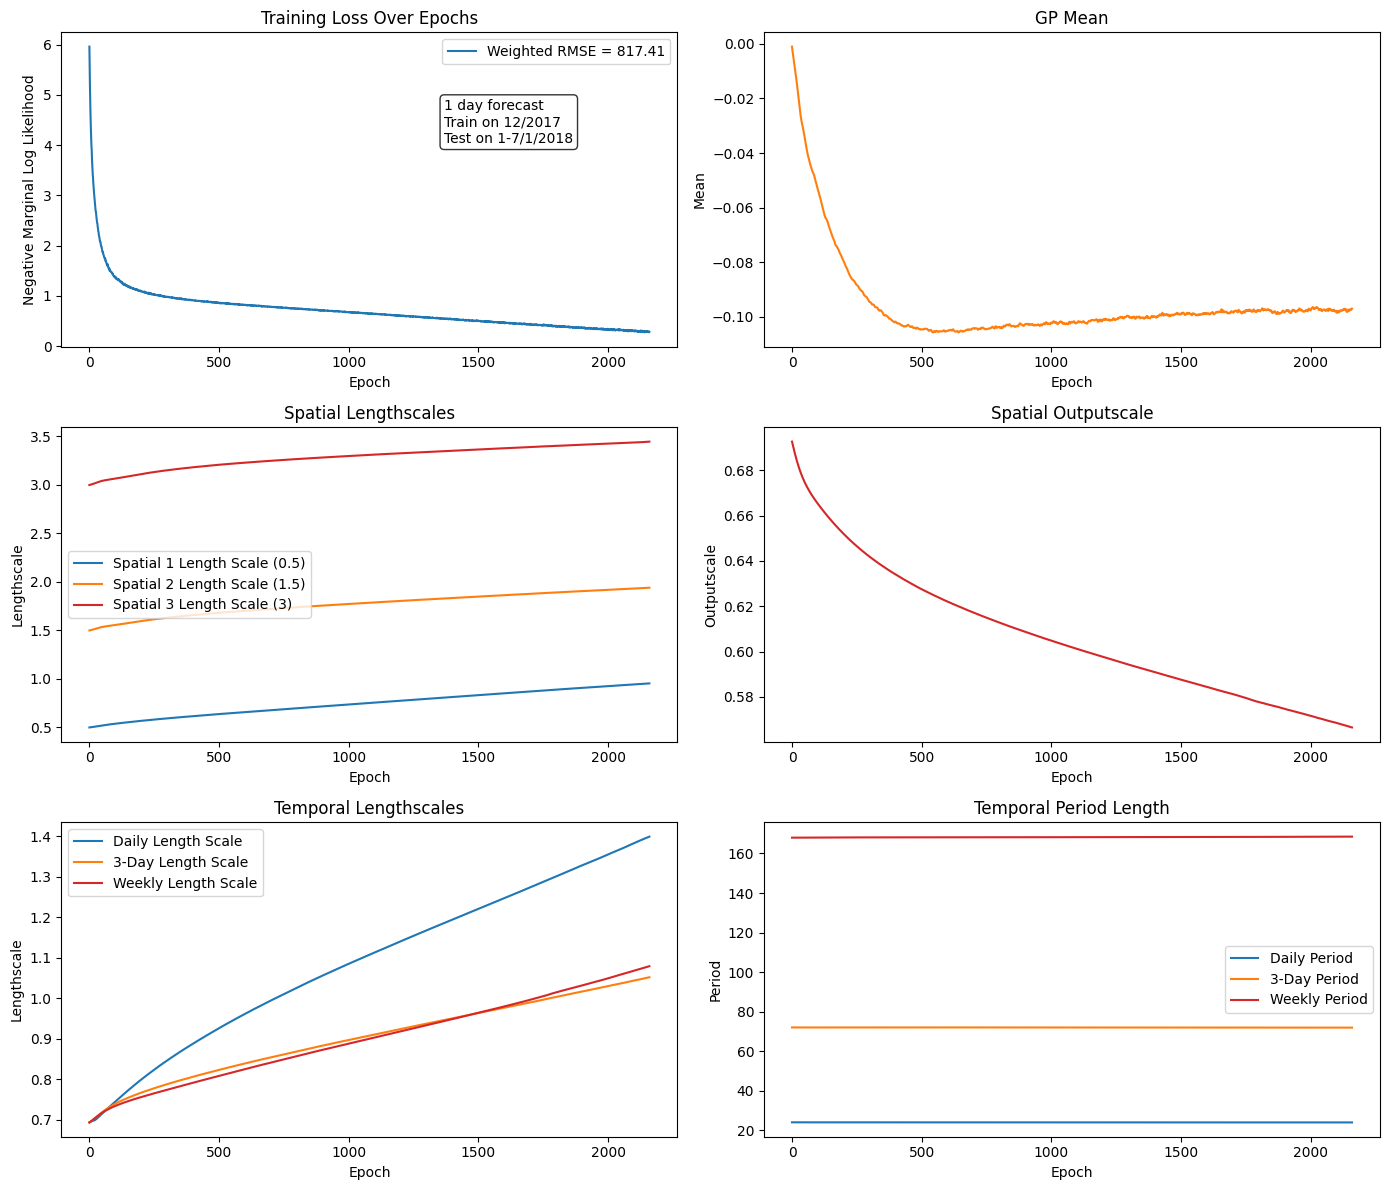

In [ ]:
import pandas as pd

# Convert your tracking list into a DataFrame
df = pd.DataFrame(hyperparams_track)
epochs_range = np.arange(len(df))

# Create a figure with 3 rows and 2 columns of subplots
fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(14, 12))

# --- Row 1 ---
# Left: Loss
axs[0, 0].plot(epochs_range, df["loss"], label=f'Weighted RMSE = {wrmse:.2f}', color='tab:blue')
axs[0, 0].set_title("Training Loss Over Epochs")
axs[0, 0].set_xlabel("Epoch")
axs[0, 0].set_ylabel("Negative Marginal Log Likelihood")
axs[0, 0].legend()

axs[0, 0].text(
    0.6215, 0.65, 
    f"1 day forecast\nTrain on 12/2017\nTest on 1-7/1/2018",
    transform=axs[0, 0].transAxes,  # interpret (x, y) as axes-relative
    fontsize=10,
    bbox=dict(facecolor='white', alpha=0.8, boxstyle='round')
)

# Right: Mean and Noise
axs[0, 1].plot(epochs_range, df["mean"], color='tab:orange', label="Mean")
axs[0, 1].set_title("GP Mean and Noise")
axs[0, 1].set_xlabel("Epoch")
axs[0, 1].set_ylabel("Mean", color='tab:orange')
axs[0, 1].tick_params(axis='y', labelcolor='tab:orange')
ax_noise = axs[0, 1].twinx()
ax_noise.plot(epochs_range, df["noise"], color='tab:blue', label="Noise")
ax_noise.set_ylabel("Noise", color='tab:blue')
ax_noise.tick_params(axis='y', labelcolor='tab:blue')

# --- Row 2 ---
# Left: Spatial lengthscales 
axs[1, 0].plot(epochs_range, df["spatial_1_lengthscale"], label='Spatial 1 Length Scale (0.5)', color='tab:blue')
axs[1, 0].plot(epochs_range, df["spatial_2_lengthscale"], label='Spatial 2 Length Scale (1.5)', color='tab:orange')
axs[1, 0].plot(epochs_range, df["spatial_3_lengthscale"], label='Spatial 3 Length Scale (3)' , color='tab:red')
axs[1, 0].set_title("Spatial Lengthscales")
axs[1, 0].set_xlabel("Epoch")
axs[1, 0].set_ylabel("Lengthscale")
axs[1, 0].legend()

# Right: Spatial outputscale
axs[1, 1].plot(epochs_range, df["spatial_outputscale"], label='Output scale from ScaleKernel', color='tab:red')
axs[1, 1].set_title("Spatial Outputscale")
axs[1, 1].set_xlabel("Epoch")
axs[1, 1].set_ylabel("Outputscale")

# --- Row 3 ---
# Left: Temporal lengthscales
axs[2, 0].plot(epochs_range, df["time_lengthscale_daily"], label='Daily Length Scale', color='tab:blue')
axs[2, 0].plot(epochs_range, df["time_lengthscale_three_days"], label='3-Day Length Scale', color='tab:orange')
axs[2, 0].plot(epochs_range, df["time_lengthscale_weekly"], label='Weekly Length Scale', color='tab:red')
axs[2, 0].set_title("Temporal Lengthscales")
axs[2, 0].set_xlabel("Epoch")
axs[2, 0].set_ylabel("Lengthscale")
axs[2, 0].legend()

# Right: Temporal periods
axs[2, 1].plot(epochs_range, df["time_period_daily"], label='Daily Period', color='tab:blue')
axs[2, 1].plot(epochs_range, df["time_period_three_days"], label='3-Day Period', color='tab:orange')
axs[2, 1].plot(epochs_range, df["time_period_weekly"], label='Weekly Period', color='tab:red')
axs[2, 1].set_title("Temporal Period Length")
axs[2, 1].set_xlabel("Epoch")
axs[2, 1].set_ylabel("Period")
axs[2, 1].legend()

plt.tight_layout()
plt.show()

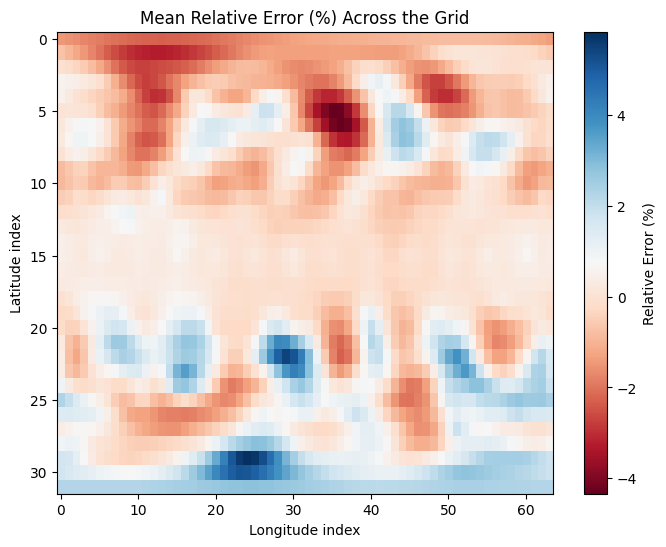

In [24]:
relative_error = (Y_pred_actual - Y_test_actual) / Y_test_actual * 100  # shape (ntime, 7, 13)
relative_error_mean = relative_error.mean(axis=0)  # shape (7, 13)

plt.figure(figsize=(8, 6))
im = plt.imshow(relative_error_mean, cmap='RdBu', aspect='auto')
plt.title('Mean Relative Error (%) Across the Grid')
plt.xlabel('Longitude index')
plt.ylabel('Latitude index')
plt.colorbar(im, label='Relative Error (%)')
plt.show()

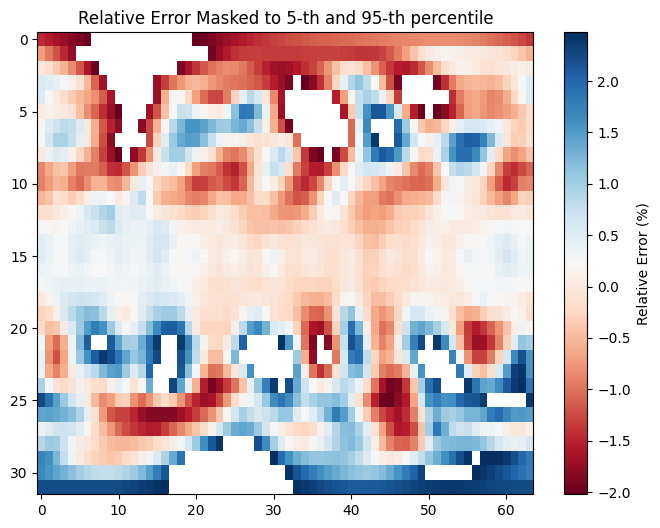

In [25]:
low_q = np.percentile(relative_error_mean, 5)
high_q = np.percentile(relative_error_mean, 95)
masked_error = np.ma.masked_outside(relative_error_mean, low_q, high_q)

plt.figure(figsize=(8, 6))
im = plt.imshow(masked_error, cmap='RdBu', aspect='auto')
plt.colorbar(im, label='Relative Error (%)')
plt.title('Relative Error Masked to 5-th and 95-th percentile')
plt.show()

In [41]:
max_idx = np.argmax(relative_error_mean)
min_idx = np.argmin(relative_error_mean)
best_idx = np.argmin(np.abs(relative_error_mean))

flat_max_idx = np.unravel_index(max_idx, relative_error_mean.shape)
flat_min_idx = np.unravel_index(min_idx, relative_error_mean.shape)
flat_best_idx = np.unravel_index(best_idx, relative_error_mean.shape)

max_err = relative_error_mean[flat_max_idx[0],flat_max_idx[1]]
min_err = relative_error_mean[flat_min_idx[0],flat_min_idx[1]]
best_err = relative_error_mean[flat_best_idx[0],flat_best_idx[1]]

print(f"Highest relative error: ({int(flat_max_idx[0])},{int(flat_max_idx[1])}), with relative error in percentage: {max_err:.3f}")
print(f"Lowest relative error: ({int(flat_min_idx[0])},{int(flat_min_idx[1])}), with relative error in percentage: {min_err:.3f}")
print(f"Smallest relative error: ({int(flat_best_idx[0])},{int(flat_best_idx[1])}), with relative error in percentage: {best_err:.3f}")

Highest relative error: (29,24), with relative error in percentage: 5.825
Lowest relative error: (6,36), with relative error in percentage: -4.338
Smallest relative error: (23,4), with relative error in percentage: -0.000


In [21]:
results = []
spatial_kernel = model.covar_module.kernels[0]
spatial1 = spatial_kernel.base_kernel.kernels[0]
spatial2 = spatial_kernel.base_kernel.kernels[1]
spatial3 = spatial_kernel.base_kernel.kernels[2]
time_sum_kernel = model.covar_module.kernels[1]
periodic1 = time_sum_kernel.kernels[0]
periodic2 = time_sum_kernel.kernels[1]
periodic3 = time_sum_kernel.kernels[2]

results.append({
    "mean": model.mean_module.constant.item(),
    "noise": likelihood.noise.item(),
    "spatial_1_lengthscale": spatial1.lengthscale.item(),
    "spatial_2_lengthscale": spatial2.lengthscale.item(),
    "spatial_3_lengthscale": spatial3.lengthscale.item(),
    "spatial_outputscale": spatial_kernel.outputscale.item(),
    "time_lengthscale_daily": periodic1.lengthscale.item(),
    "time_period_daily": periodic1.period_length.item(),
    "time_lengthscale_three_days": periodic2.lengthscale.item(),
    "time_period_three_days": periodic2.period_length.item(),
    "time_lengthscale_weekly": periodic3.lengthscale.item() ,
    "time_period_weekly": periodic3.period_length.item(),
})
results

[{'mean': -0.09700388581384803,
  'noise': 0.19761613467212463,
  'spatial_1_lengthscale': 0.9536726808304726,
  'spatial_2_lengthscale': 1.9403997686183259,
  'spatial_3_lengthscale': 3.4465989689353616,
  'spatial_outputscale': 0.566550334424382,
  'time_lengthscale_daily': 1.3985730817735902,
  'time_period_daily': 23.939085520611158,
  'time_lengthscale_three_days': 1.0517304466333919,
  'time_period_three_days': 71.89972684445081,
  'time_lengthscale_weekly': 1.0789872598361334,
  'time_period_weekly': 168.5304322130449}]

## Load saved model

In [28]:
lead_time = 24 # units of hours
space_subsample_ips = 5 # regular subsampling as inducing points
time_subsample_ips = 6 # regular subsampling as inducing points
space_subsample = 1
time_subsample = 1
batch_size = 2048

X_train, Y_train = create_data(data_train, data_test, lead_time, space_subsample, time_subsample)

# Inducing points technique
inducing_points = X_train[::time_subsample_ips, ::space_subsample_ips, ::space_subsample_ips,:].reshape(-1, 4)
X_train = X_train.view(-1,4) # Shape: (ntime*nlat*nlon, 4)
print(f"Number of inducing points / Total number of points: {inducing_points.size(0)/X_train.size(0)}")

train_dataset = TensorDataset(X_train, Y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)

Processing Training Dataset
Combined coords info --> Shape: torch.Size([720, 32, 64, 4]), Mem: 45.00 MB
Target info --> Shape: torch.Size([1474560]), Mem: 5.62 MB
Number of inducing points / Total number of points: 0.007405598958333333


In [13]:
model = GPModel(inducing_points).to(device)
likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device)

model.load_state_dict(torch.load("STGP-weather-forecasting/saved_models/vargp_model.pth"))
likelihood.load_state_dict(torch.load("STGP-weather-forecasting/saved_models/vargp_likelihood.pth"))

<All keys matched successfully>

In [ ]:
model.eval()
likelihood.eval()
train_mean = []
train_std = []
with torch.no_grad():
    for x_batch, y_batch in train_loader:
        pred_train = likelihood(model(x_batch))
        train_mean.append(pred_train.mean)
        train_std.append(pred_train.stddev)
    train_mean = torch.cat(train_mean, dim=0)  
    train_std = torch.cat(train_std, dim=0) 
    
train_mean = train_mean.detach().cpu().numpy()  
train_std = train_std.detach().cpu().numpy()  
Y_train = Y_train.detach().cpu().numpy()

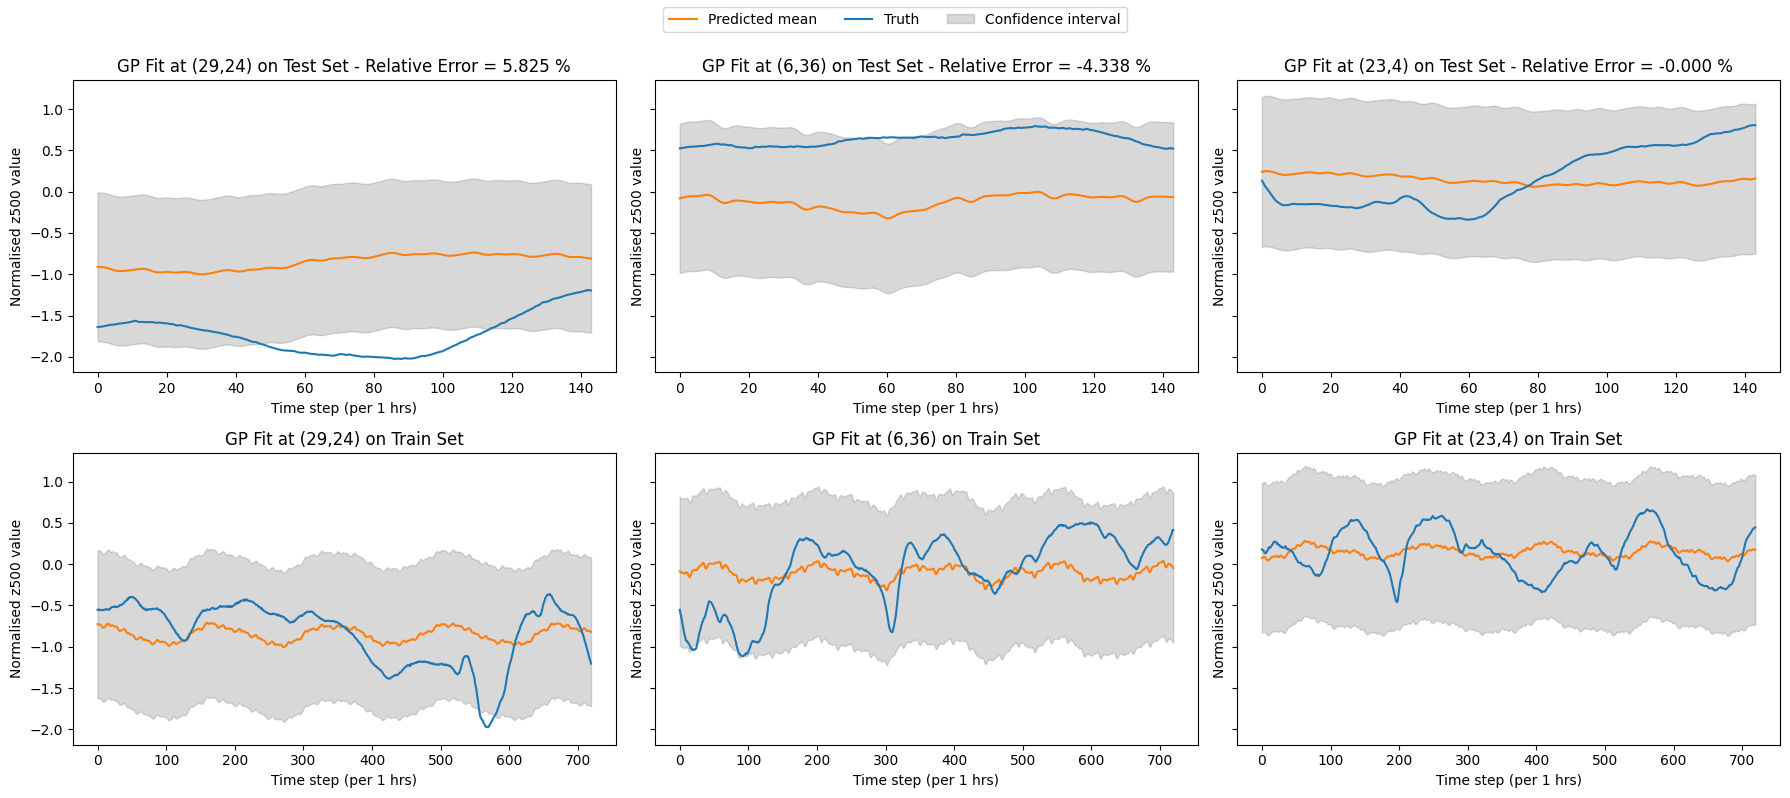

In [55]:
# Create a 2x3 figure
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=False, sharey=True)

idx = [max_idx, min_idx, best_idx]
val = [max_err, min_err, best_err]

for i, p_idx in enumerate(idx):
    flat_idx = np.unravel_index(p_idx, relative_error_mean.shape)
    ax = axes[0, i]  

    pred_vals = Y_pred.reshape(-1)[p_idx::(nlat*nlon)]
    truth_vals = Y_test.reshape(-1)[p_idx::(nlat*nlon)]
    std_vals = Y_std.reshape(-1)[p_idx::(nlat*nlon)]

    ax.plot(pred_vals, label='Predicted mean', color='tab:orange')
    ax.plot(truth_vals, label='Truth', color='tab:blue')
    ax.fill_between(np.arange(len(pred_vals)),
                    pred_vals - 2 * std_vals,
                    pred_vals + 2 * std_vals,
                    alpha=0.3, color='tab:gray', label='Confidence interval')
    ax.set_xlabel(f"Time step (per {time_subsample} hrs)")
    ax.set_ylabel("Normalised z500 value")
    ax.set_title(f"GP Fit at ({int(flat_idx[0])},{int(flat_idx[1])}) on Test Set - Relative Error = {val[i]:.3f} %")

for i, p_idx in enumerate(idx):
    flat_idx = np.unravel_index(p_idx, relative_error_mean.shape)
    ax = axes[1, i]  

    pred_vals = train_mean.reshape(-1)[p_idx::(nlat*nlon)]
    truth_vals = Y_train.reshape(-1)[p_idx::(nlat*nlon)]
    std_vals = train_std.reshape(-1)[p_idx::(nlat*nlon)]

    ax.plot(pred_vals, label='Predicted mean', color='tab:orange')
    ax.plot(truth_vals, label='Truth', color='tab:blue')
    ax.fill_between(np.arange(len(pred_vals)),
                    pred_vals - 2 * std_vals,
                    pred_vals + 2 * std_vals,
                    alpha=0.3, color='tab:gray', label='Confidence interval')
    ax.set_xlabel(f"Time step (per {time_subsample} hrs)")
    ax.set_ylabel("Normalised z500 value")
    ax.set_title(f"GP Fit at ({int(flat_idx[0])},{int(flat_idx[1])}) on Train Set")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3)

plt.tight_layout(rect=[0, 0, 1, 0.95]) 
plt.show()